In [1]:
from pathlib import Path
import sys

# Add parent directory to path for imports
sys.path.insert(0, str(Path().resolve().parent))

from src.JUDITHDataset import JUDITHDataset
from src.crack_identification import enhance_cracks, crack_detector, find_cracks

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.ticker import EngFormatter
fmt = EngFormatter(unit="m", places=None, sep=" ")

In [2]:
dataset = JUDITHDataset(preload=True)
print('Metadata keys:', dataset.metadata.keys())
print('Unique materials:', dataset.unique_meta['material'])

print('Unique base temperatures:', dataset.unique_meta['base_temp'])
print('Unique fluxes:', dataset.unique_meta['flux'])

crack_dataset = dataset.filter_by_metadata(scale=1e-3, detector='QBSD')

Metadata keys: dict_keys(['filename', 'material', 'loadtype', 'label', 'base_temp', 'flux', 'scale', 'detector', 'resolution', 'crack_density'])
Unique materials: ['M192 - W-UHP' 'M193 - WVMW' 'M194 - WTa1' 'M195 - WTa5' 'M196 - pure W']
Unique base temperatures: [ 20. 100. 150. 200. 400. 600.]
Unique fluxes: [ 189.  283.  378.  567.  756. 1135. 1512.]


## Visualize cracks

### Selected conditions

In [3]:
scale = 1e-3
base_temp = 20
flux = 378
# material = 'M192 - W-UHP'
detector = 'QBSD'

### Examples of crack patterns for given material in a test matrix 

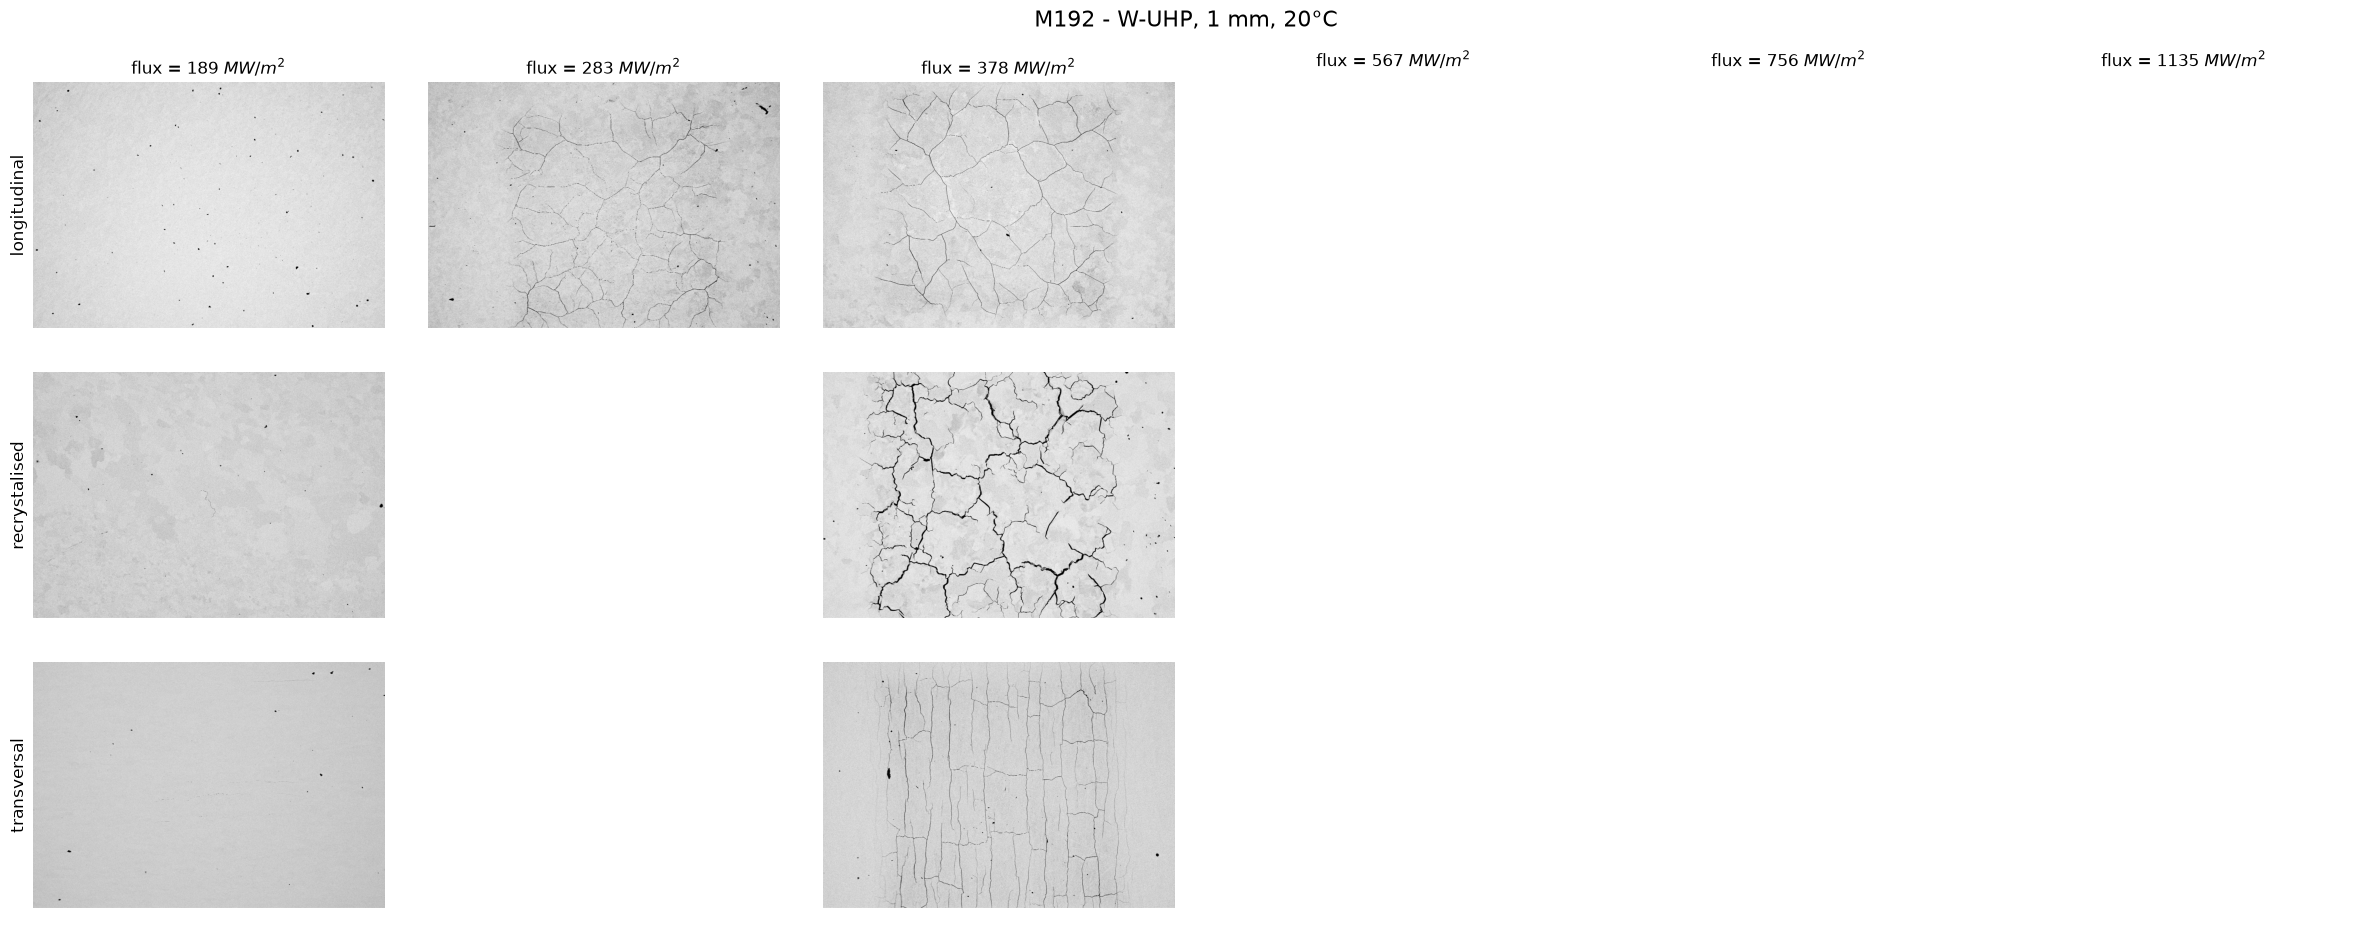

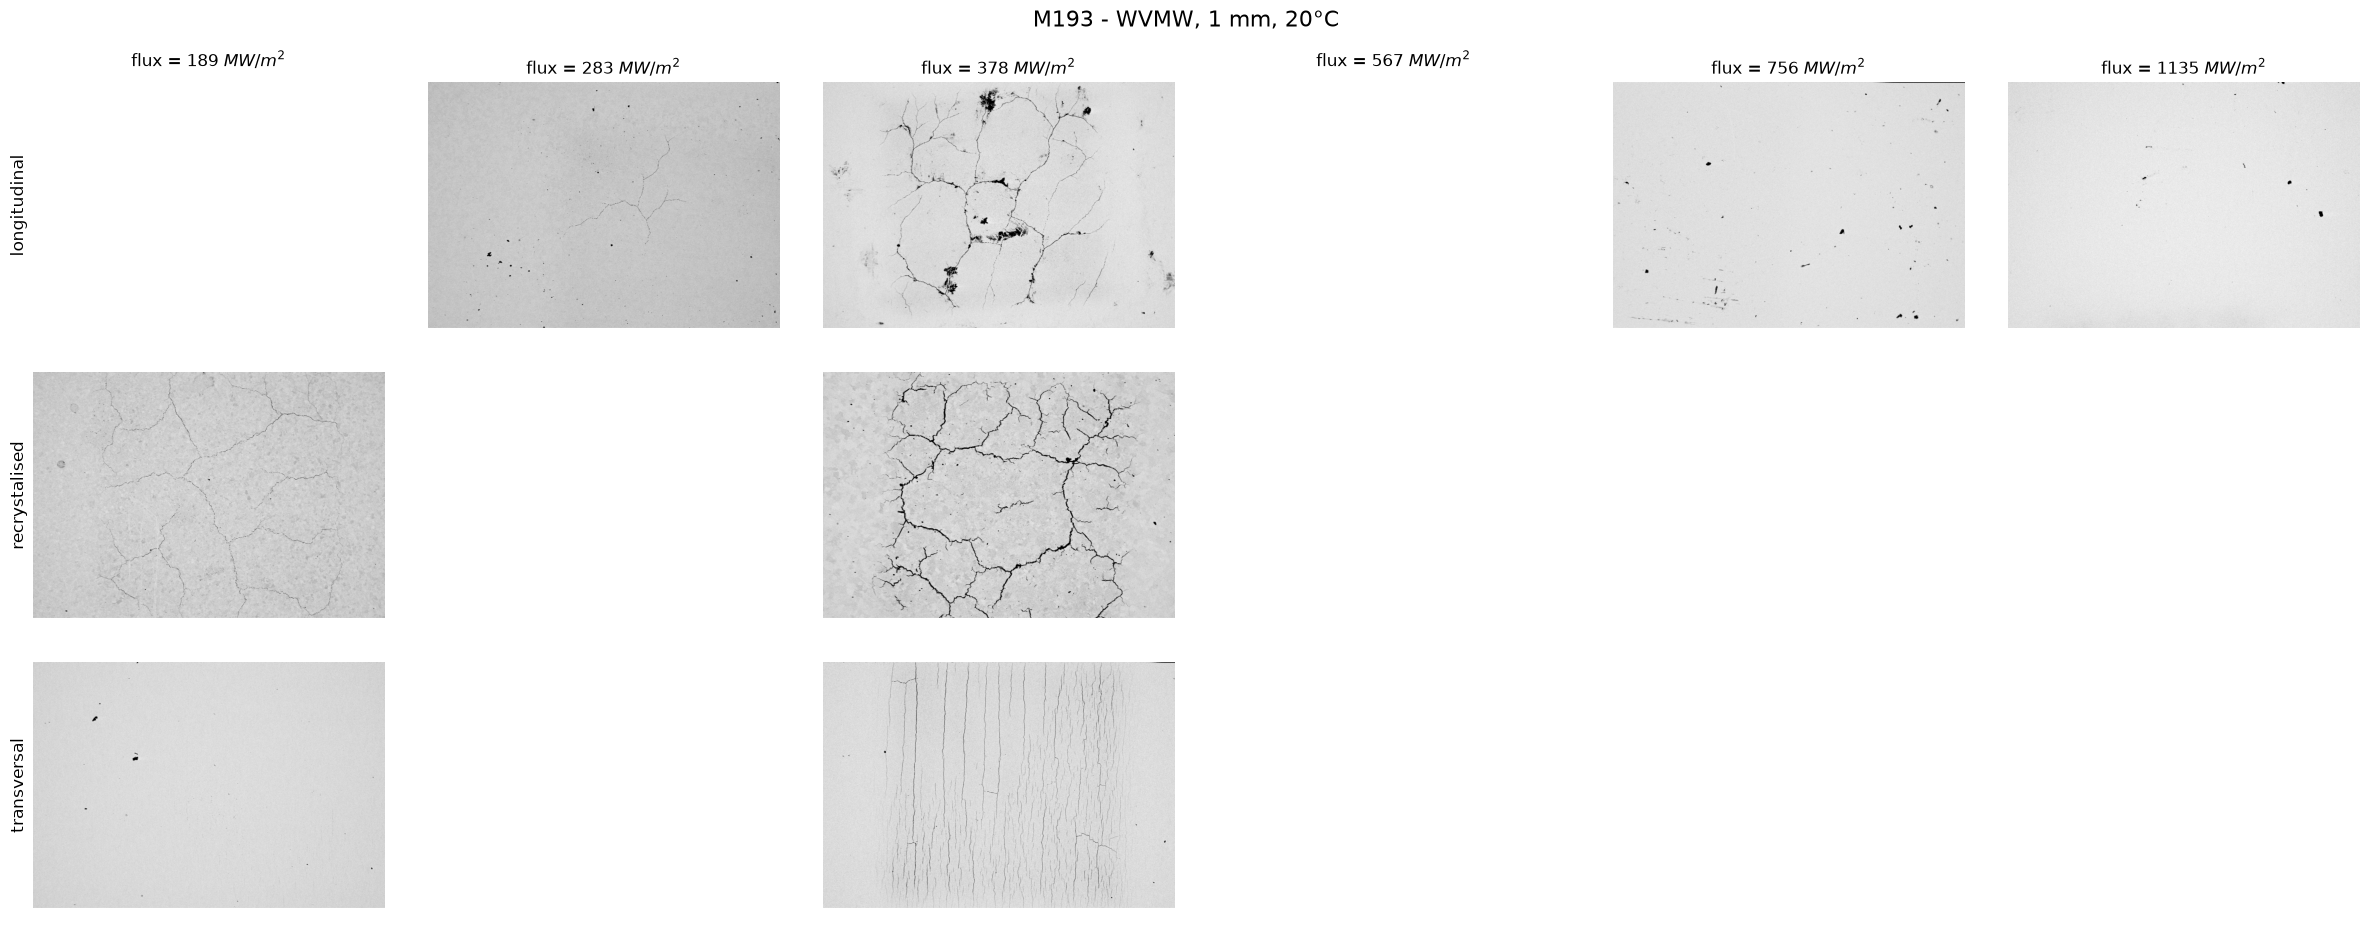

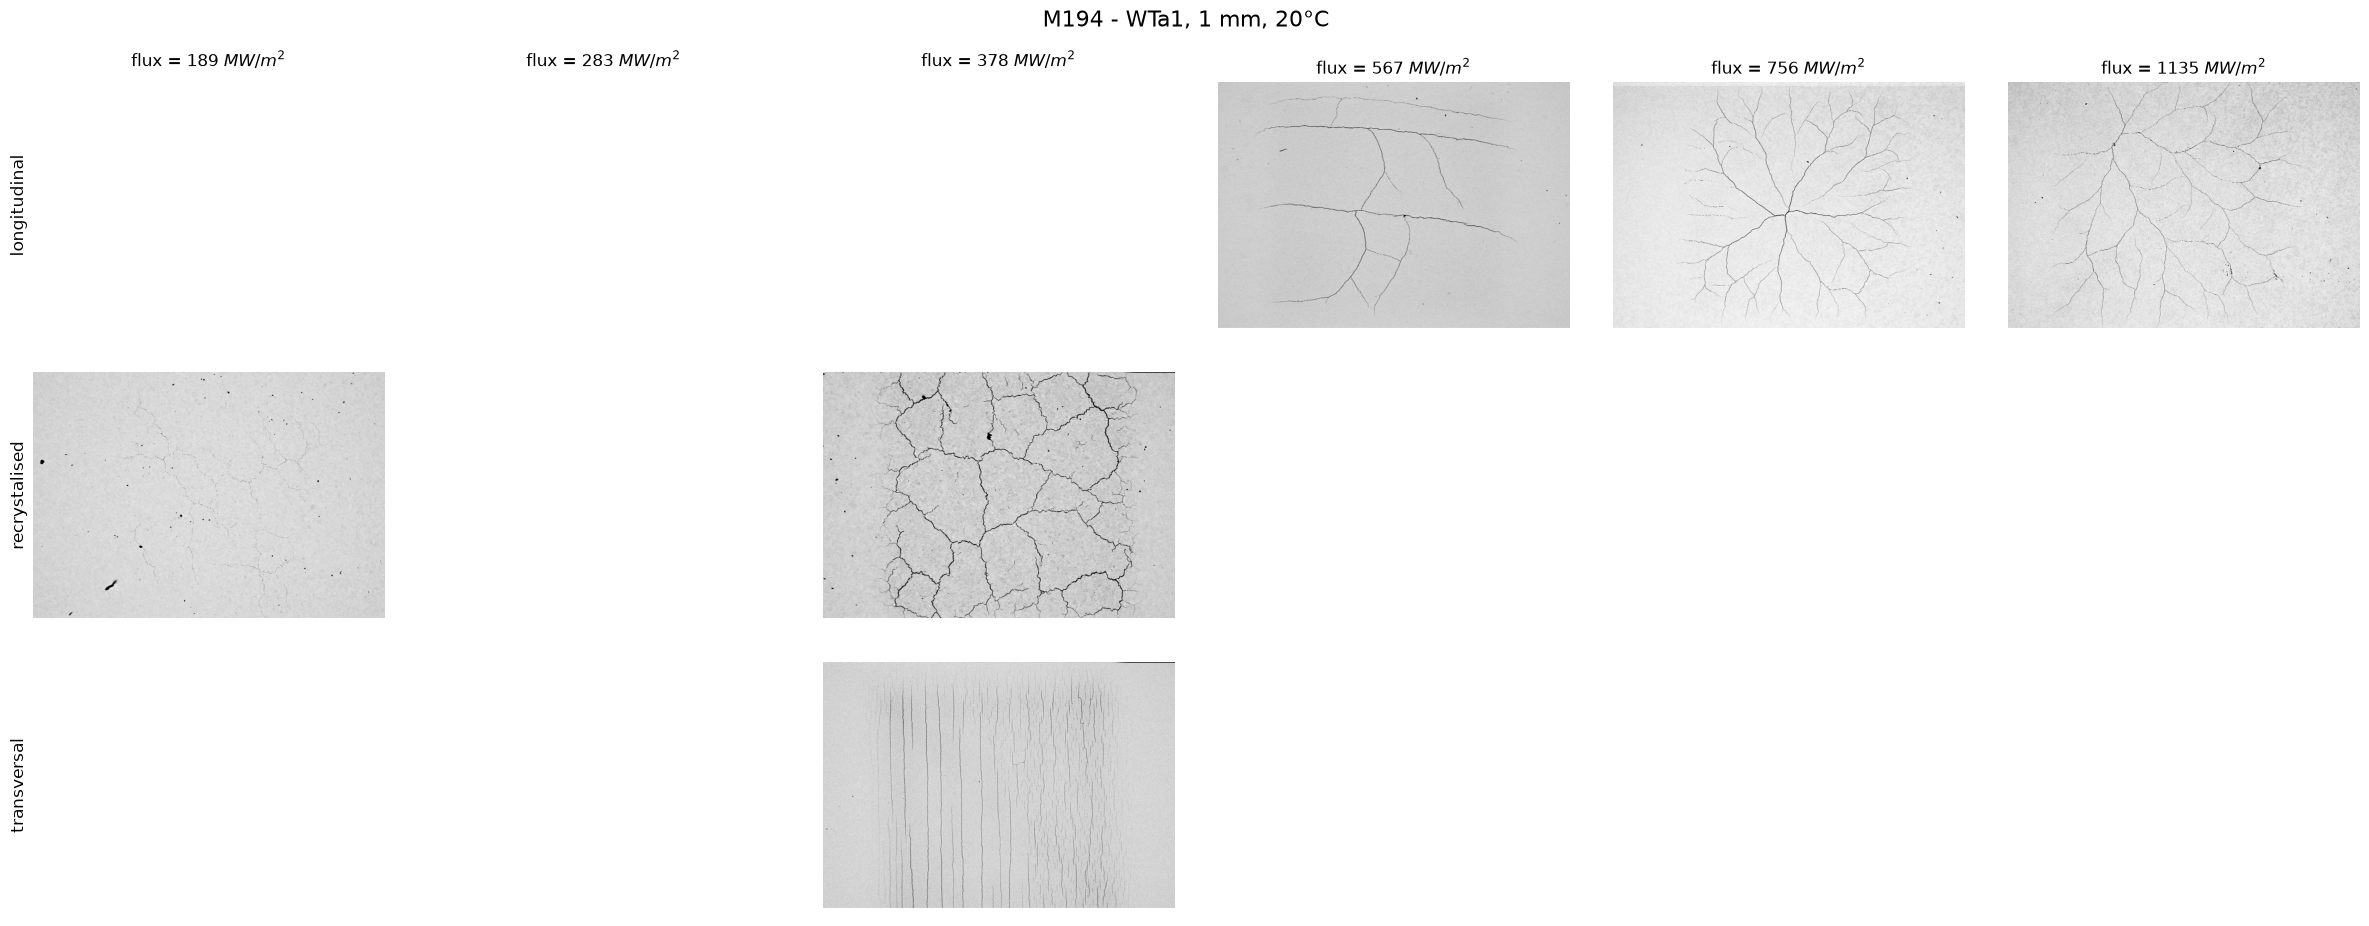

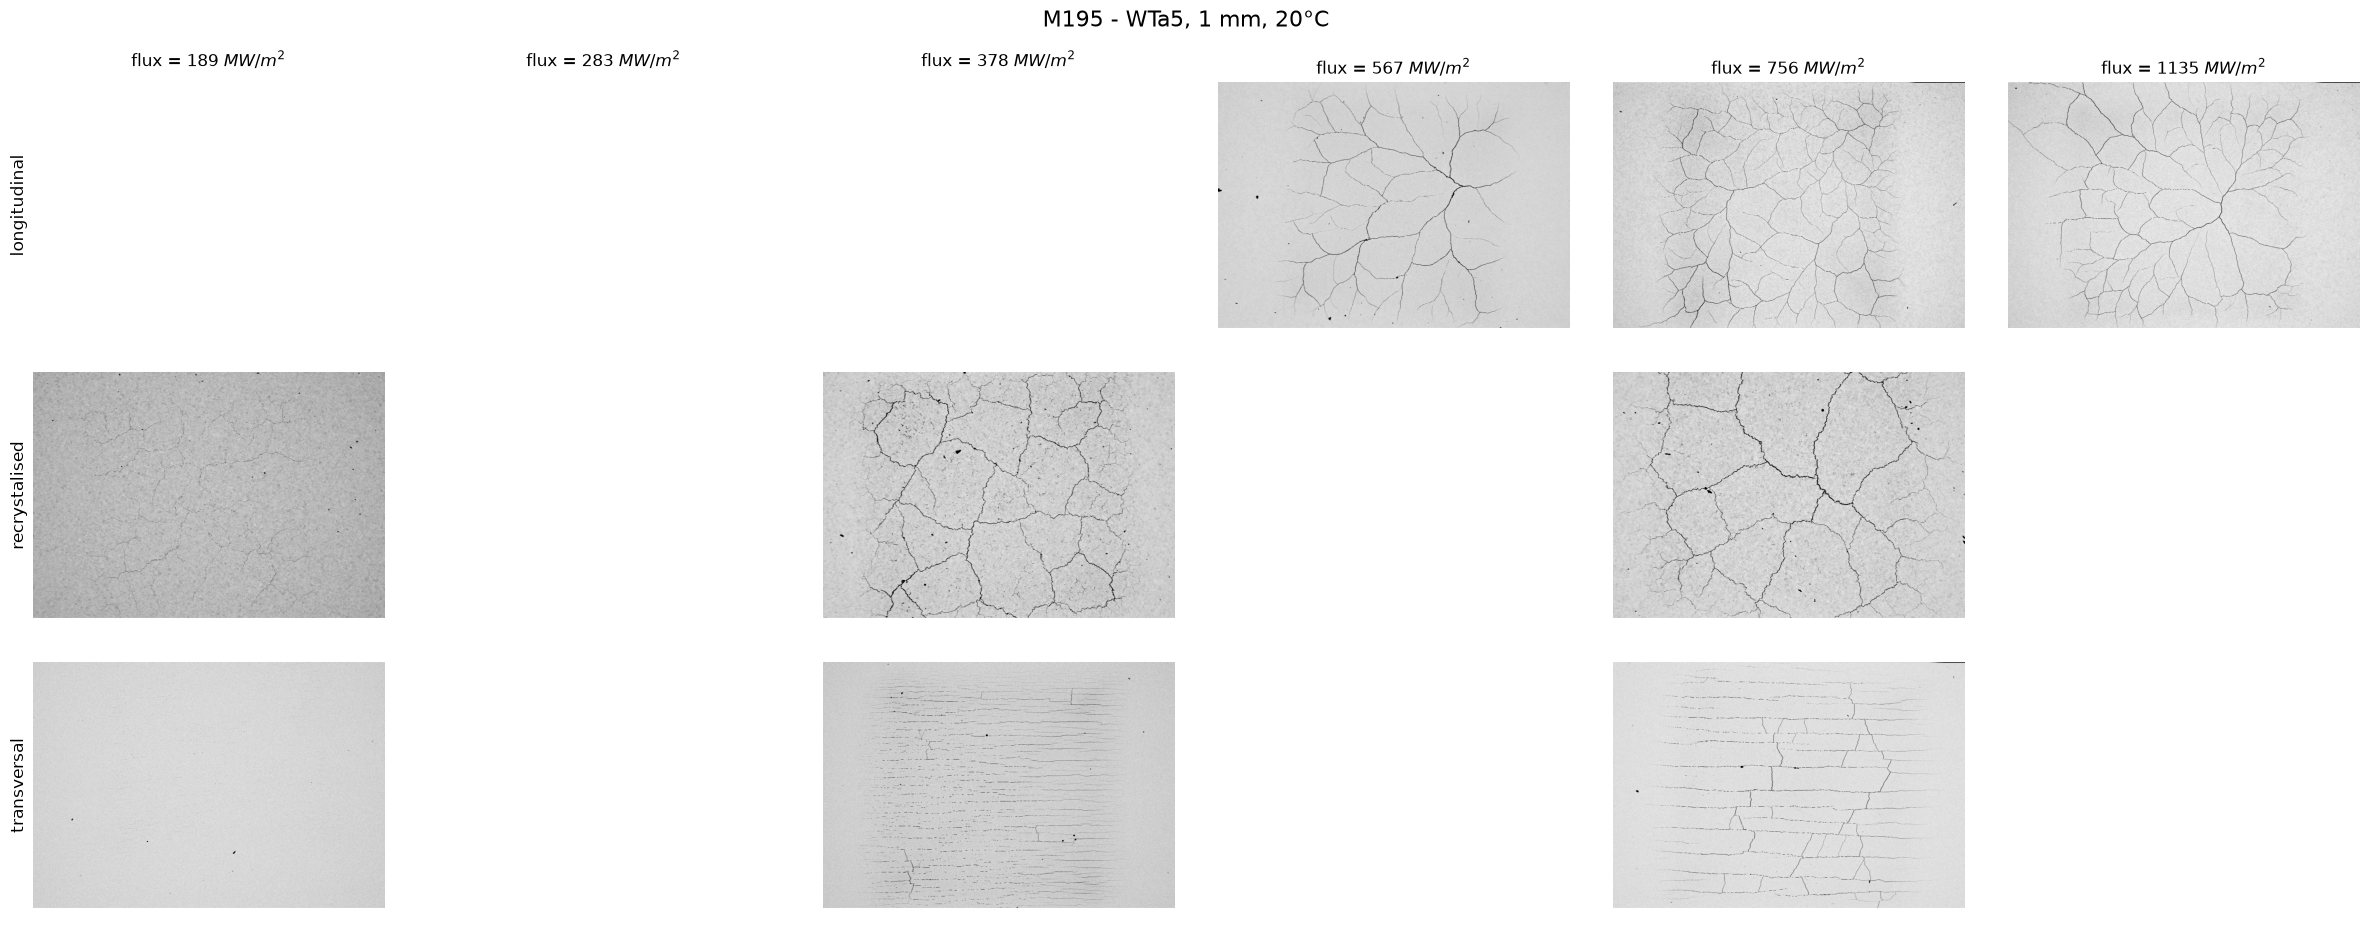

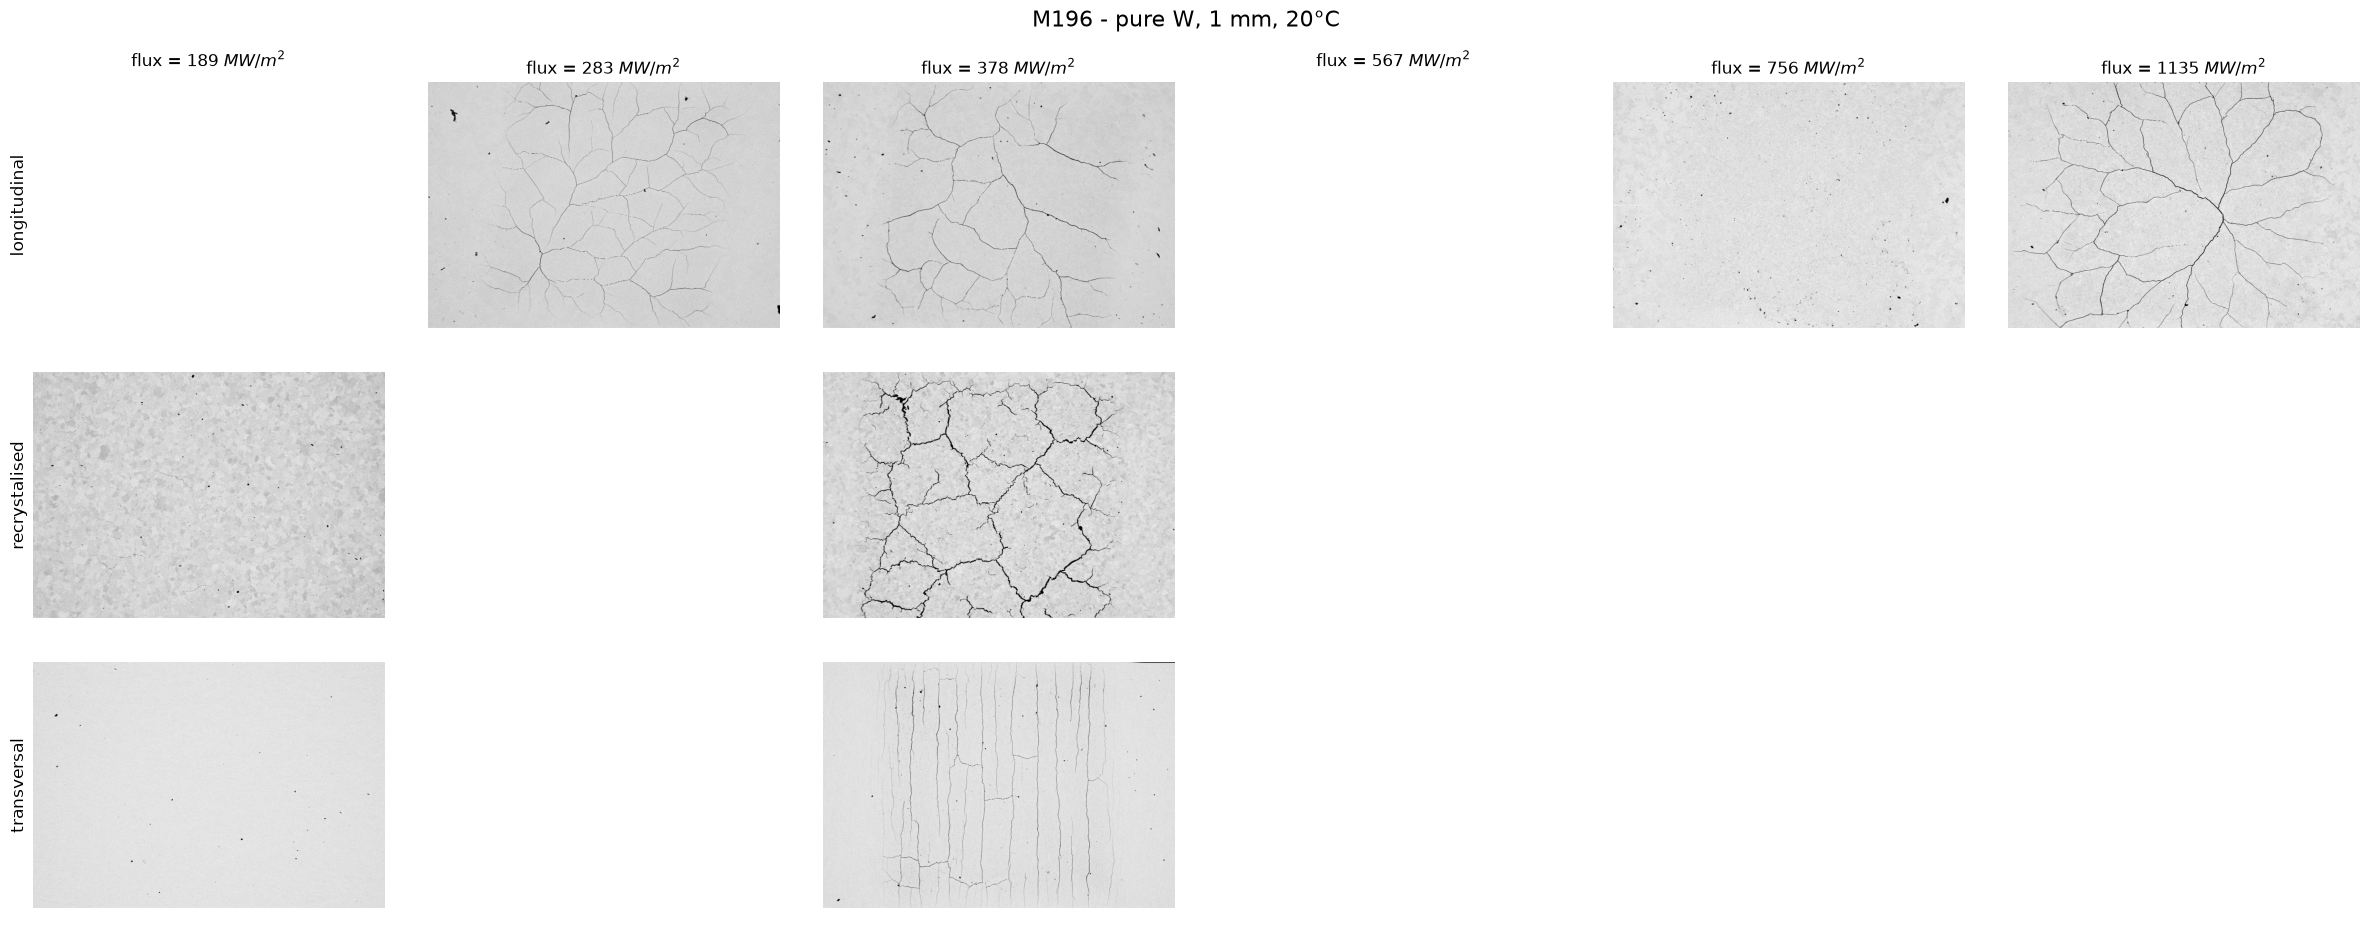

In [4]:
for materiali in dataset.unique_meta['material']:
    num_cols = len(np.unique(dataset.metadata['flux'])[:-1])
    num_rows = len(dataset.unique_meta['loadtype'])

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols,3*num_rows))
    fig.tight_layout(h_pad=0., w_pad=0.)

    for axj,(load_typei, axrow) in enumerate(zip(dataset.unique_meta['loadtype'], axes)):
        for axi, (fluxi, ax) in enumerate(zip(dataset.unique_meta['flux'], axrow)):
            filtered_dataset = dataset.filter_by_metadata(
                material=materiali,
                scale=scale,
                loadtype=load_typei,
                detector='QBSD',
                flux=fluxi,
                base_temp=base_temp)

            if len(filtered_dataset)>0:
                ax.imshow(filtered_dataset.data[0], cmap='gray')
            if axi==0:
                ax.set_ylabel(f"{load_typei}", fontsize=12)
            if axj==0:
                ax.set_title(f"flux = {int(fluxi)} "+r"$MW/m^2$", fontsize=12)
            # Hide x-axis ticks and labels
            ax.set_xticks([]) #
            ax.set_xticklabels([])
            # Hide y-axis ticks and labels
            ax.set_yticks([]) #
            ax.set_yticklabels([])
            # Hide spines
            for spine in ax.spines.values():
                spine.set_visible(False)
    plt.suptitle(f"{materiali}, {fmt(scale)}, {base_temp}°C", fontsize=16, x=0.5, y=1.05)
    plt.show()

### Show selected images / pre-processing / cracks

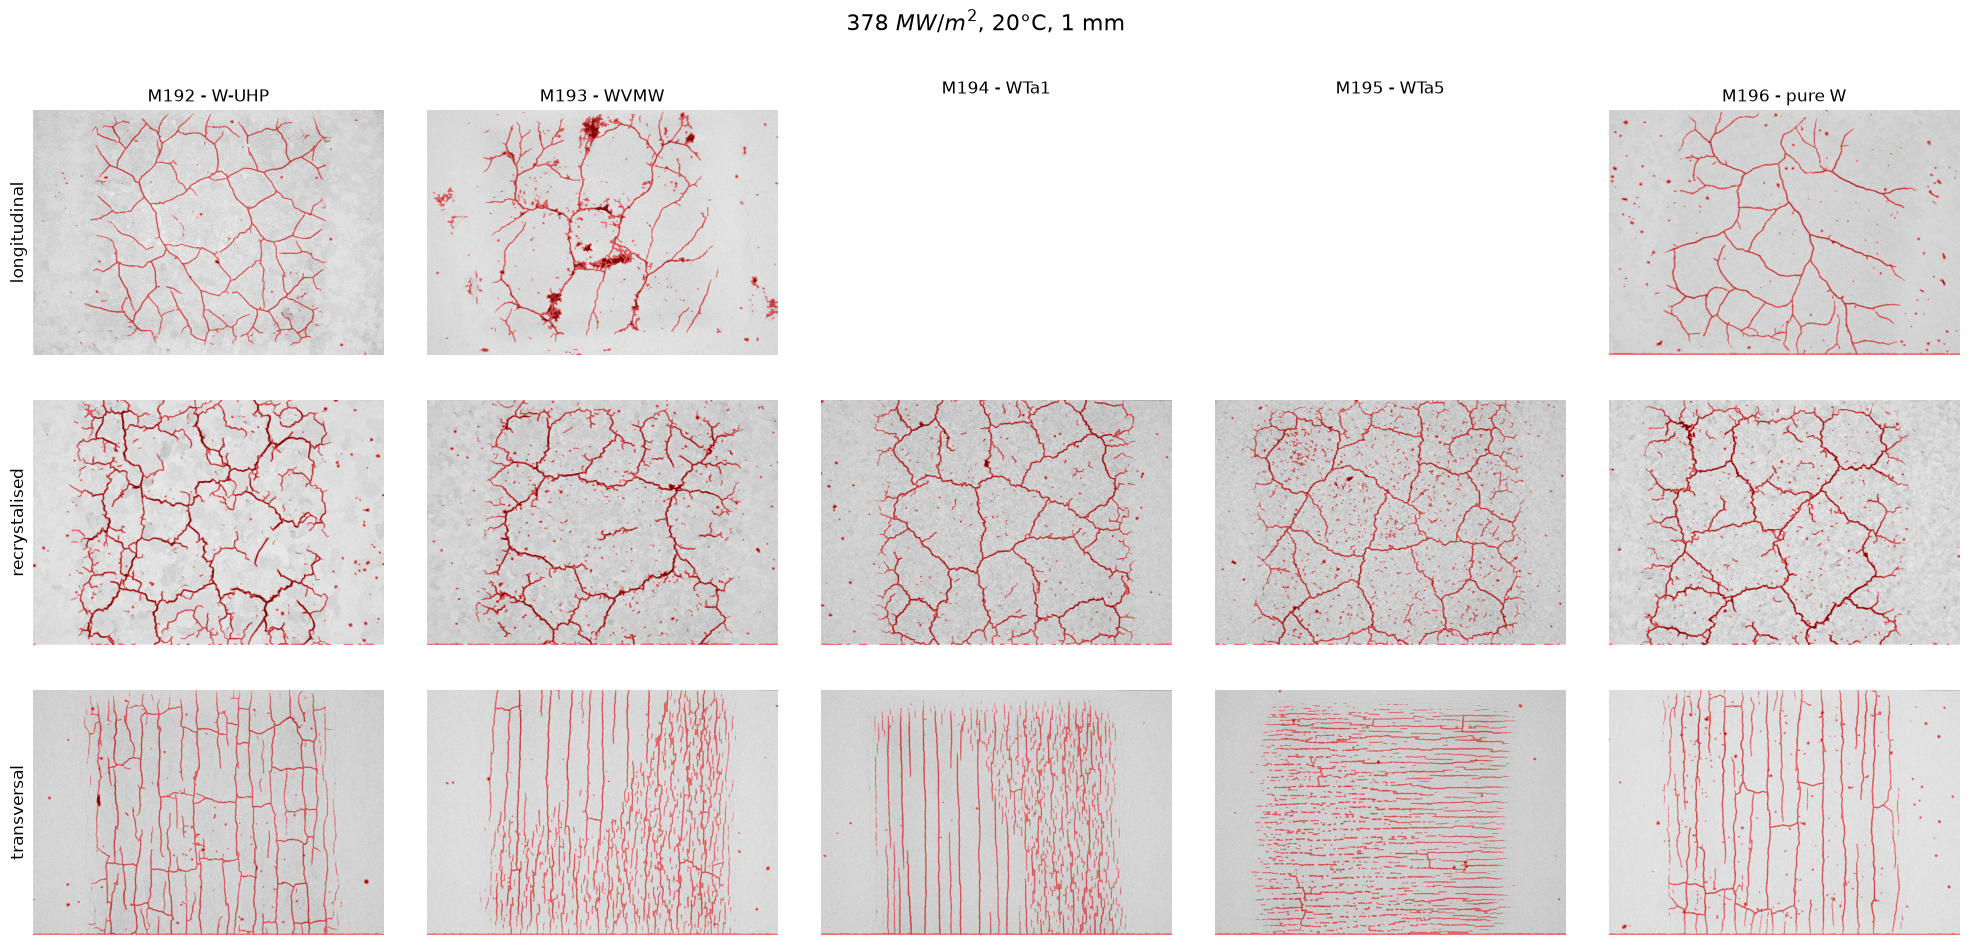

In [5]:
what_to_show = 'overlay' # 'selected images', 'preprocessing', 'cracks', 'overlay'

num_cols = len(dataset.unique_meta['material'])
num_rows = len(dataset.unique_meta['loadtype'])

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols,3*num_rows))
fig.tight_layout(h_pad=0., w_pad=0.)

for axj,(load_typei, axrow) in enumerate(zip(dataset.unique_meta['loadtype'], axes)):
    for axi, (materiali, ax) in enumerate(zip(dataset.unique_meta['material'], axrow)):
        filtered_dataset = dataset.filter_by_metadata(
            material=materiali,
            scale=scale,
            loadtype=load_typei,
            detector='QBSD',
            flux=flux,
            base_temp=base_temp)

        if len(filtered_dataset)>0:
            img = filtered_dataset.data[0]
            if what_to_show=='preprocessing':
                img = enhance_cracks(img)
            elif what_to_show=='cracks':
                img = find_cracks(img)
            ax.imshow(img, cmap='gray')
            if what_to_show=='overlay':
                cracks = find_cracks(img)
                ax.imshow(np.ma.masked_where(~cracks.astype(bool), cracks), cmap='autumn', alpha=0.5)

        if axi==0:
            ax.set_ylabel(f"{load_typei}", fontsize=12)
        if axj==0:
            ax.set_title(f"{materiali}", fontsize=12)
        # Hide x-axis ticks and labels
        ax.set_xticks([]) #
        ax.set_xticklabels([])
        # Hide y-axis ticks and labels
        ax.set_yticks([]) #
        ax.set_yticklabels([])
        # Hide spines
        for spine in ax.spines.values():
            spine.set_visible(False)
plt.suptitle(f"{int(flux)} "+r"$MW/m^2$, "+f"{base_temp}°C, {fmt(scale)}", fontsize=16, x=0.5, y=1.08)
plt.show()

## Visualize crack densities

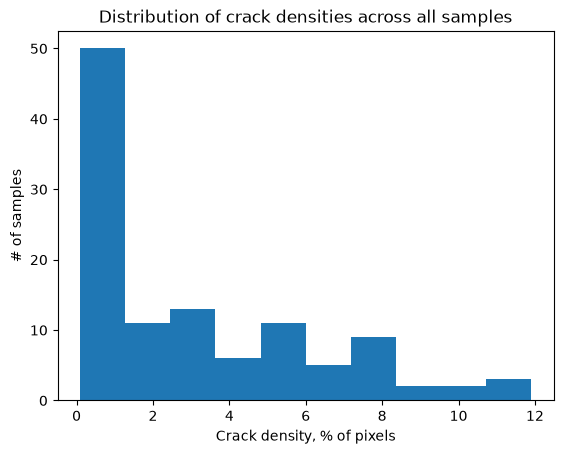

In [6]:
all_crack_densities = crack_dataset.metadata['crack_density'][np.isnan(crack_dataset.metadata['crack_density'])==False]

_,label_edges,_ = plt.hist(all_crack_densities, bins=10)
label_edges[0] = 0
label_edges[-1] += 1e-3 # ensure max value is included in last bin
plt.title('Distribution of crack densities across all samples')
plt.xlabel('Crack density, % of pixels')
plt.ylabel('# of samples')
plt.show()

# crack_labels = np.digitize(np.array(crack_densities)/100, bins=label_edges)

# crack_densities_labels = {}
# for key in crack_densities_dict.keys():
#     crack_densities_labels[key] = np.digitize(crack_densities_dict[key], bins=label_edges)

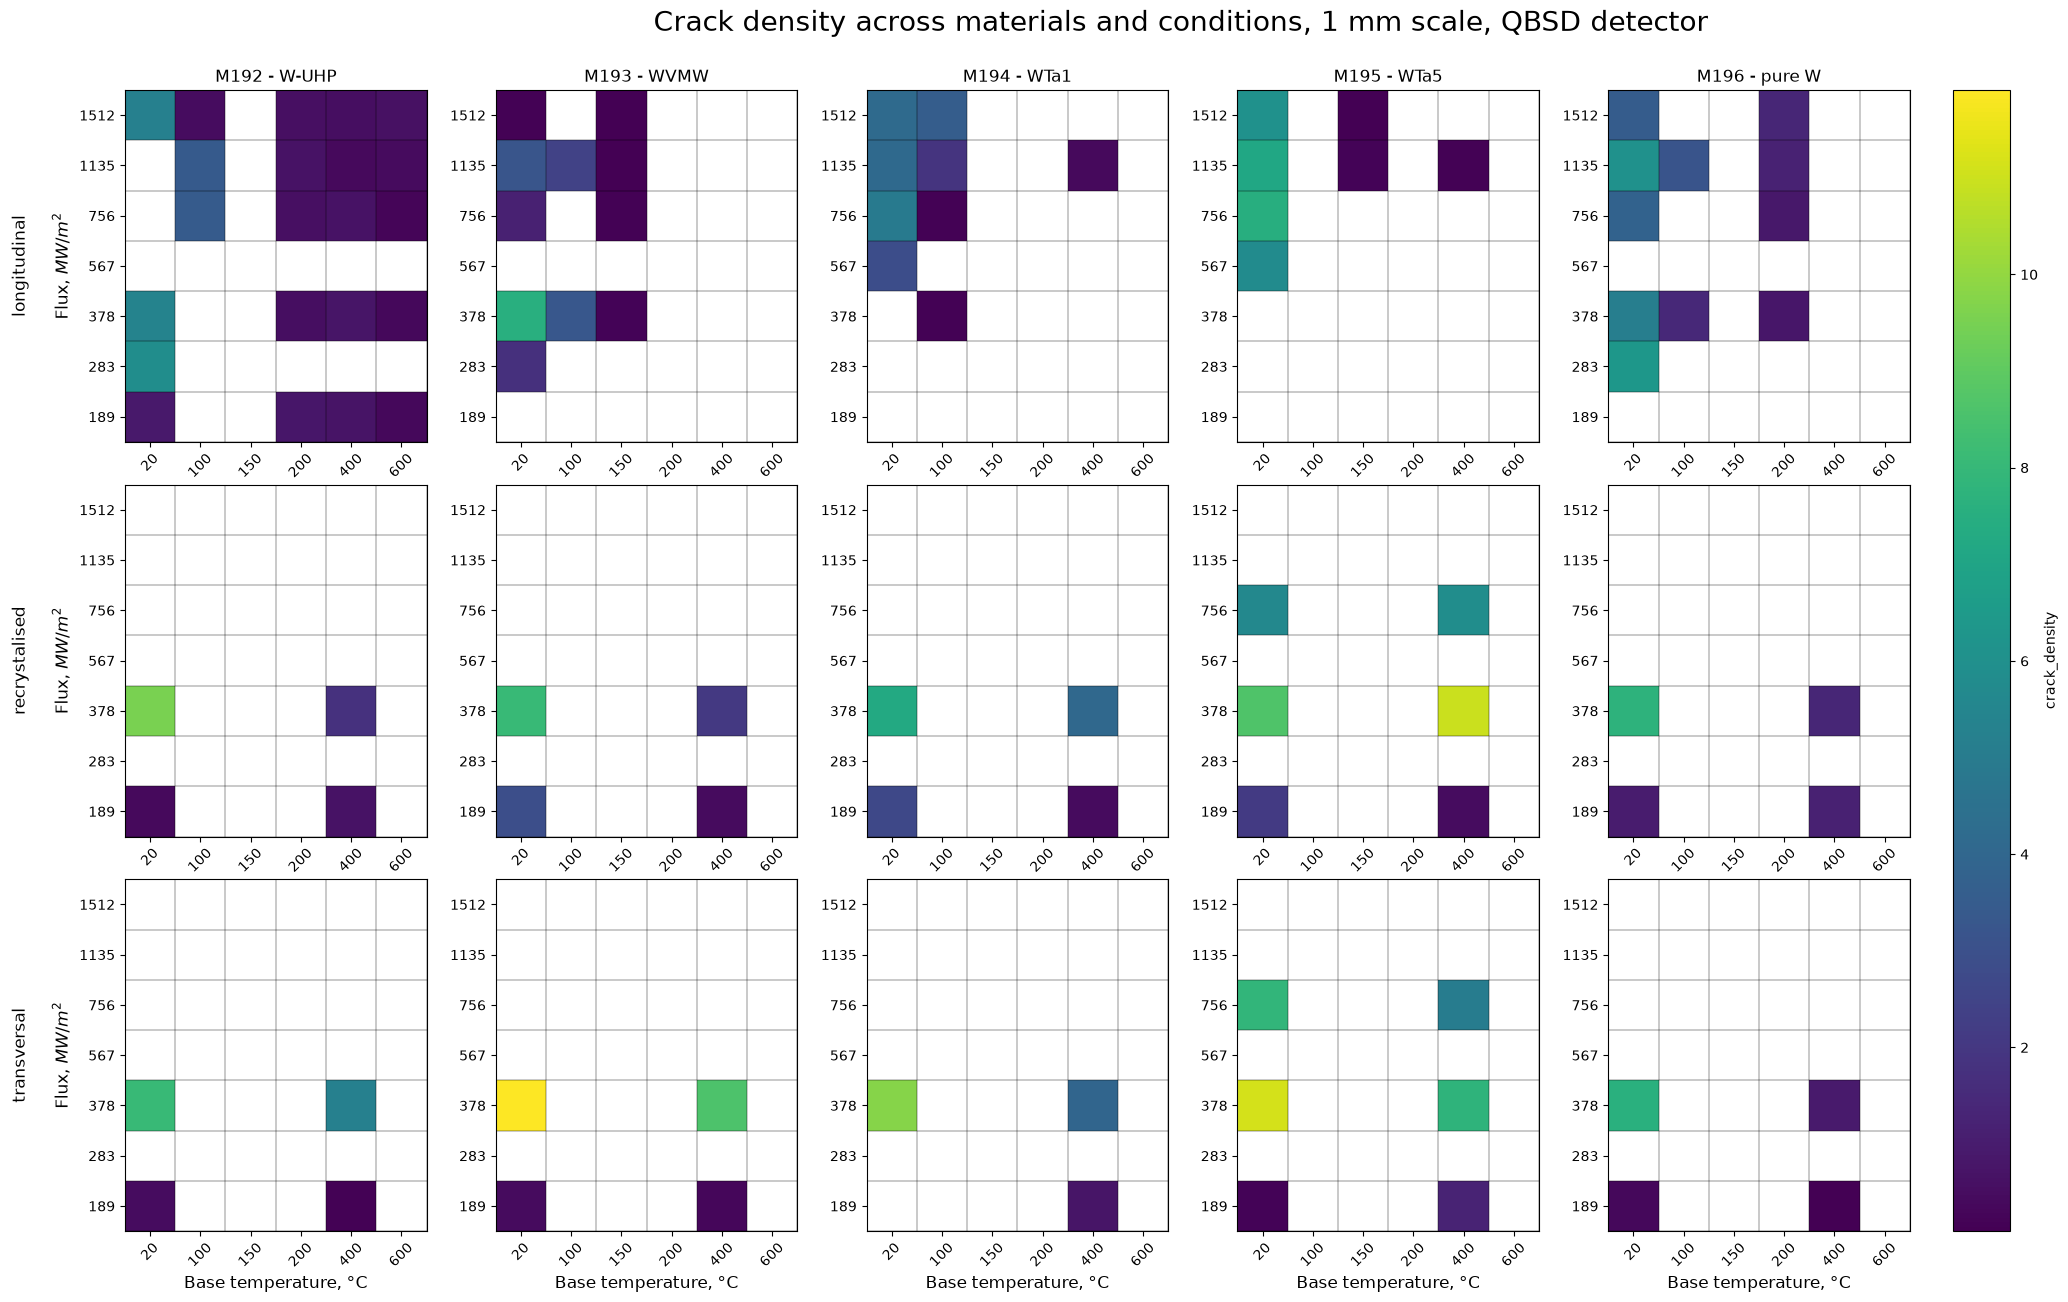

In [ ]:
# crack_dataset.plot_test_matrix(field='crack_density', cmap='viridis', what_to_show='heatmaps')
# crack_dataset.plot_test_matrix(field='crack_density', cmap='viridis', what_to_show='circle maps')
crack_dataset.plot_test_matrix(field='grain_size_tv_min', cmap='viridis', what_to_show='heatmaps')